# its a file for setting up how to take user input as the graph started

In [15]:
import os
from dotenv import load_dotenv
load_dotenv()
try:
    os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')
    print("GROQ API KEY loaded successfully")
except:
    print("GROQ API KEY not loaded")

GROQ API KEY loaded successfully


In [16]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="openai/gpt-oss-20b")
result=llm.invoke("HEy")
print(result.content)

Hey! How can I help you today?


In [17]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]

llm_with_tools=llm.bind_tools(tools)

In [18]:
from langgraph.graph import StateGraph, START, END , MessagesState
from typing_extensions import TypedDict
from pydantic import BaseModel
from langchain_core.messages import AIMessage,HumanMessage , SystemMessage
from langgraph.prebuilt import ToolNode , tools_condition
from IPython.display import display , Image
from langgraph.checkpoint.memory import InMemorySaver

In [19]:
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")


def assistant(state:MessagesState):
    return {"messages":[llm_with_tools.invoke([sys_msg] + state["messages"])]}

In [20]:
def human_feed(state:MessagesState):
    pass

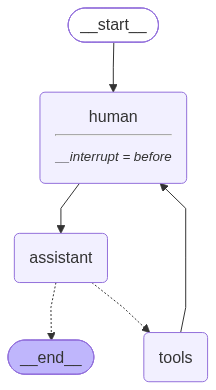

In [21]:



graph=StateGraph(MessagesState)
graph.add_node("assistant",assistant)
graph.add_node("human",human_feed)
graph.add_node("tools",ToolNode(tools))

graph.add_edge(START,"human")
graph.add_edge("human","assistant")
graph.add_conditional_edges("assistant",tools_condition)
graph.add_edge("tools","human")
graph.add_edge("assistant",END)
memory=InMemorySaver()
graph=graph.compile(interrupt_before=["human"],checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
thread={"configurable":{"thread_id":"1"}}
initial_input={"messages":HumanMessage(content="Multiply 2 and 3")}


for event in graph.stream(initial_input,thread,stream_mode="values"):
    for m in event['messages']:
        m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [23]:

for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_aed8afef-b14a-4f96-ad82-1e310341d107)
 Call ID: fc_aed8afef-b14a-4f96-ad82-1e310341d107
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [25]:
graph.update_state(thread,{"messages":[HumanMessage(content="No, actually multiply 15 and 5!")]})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1a3749-45cf-6016-8004-72b162291dae'}}

In [26]:
for event in graph.stream(None,thread,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

No, actually multiply 15 and 5!
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_a91347e3-9497-4b16-8c32-f2691d9851e5)
 Call ID: fc_a91347e3-9497-4b16-8c32-f2691d9851e5
  Args:
    a: 15
    b: 5
================================= Tool Message =================================
Name: multiply

75


In [ ]:

initial_input = {"messages": "Multiply 2 and 3"}


thread = {"configurable": {"thread_id": "5"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()
    
    

user_input=input("Tell me how you want to update the state:")

graph.update_state(thread,{"messages":user_input},as_node="human")

# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

instead of multiply, add
================================== Ai Message ==================================
Tool Calls:
  add (fc_24c192fc-c5e0-4666-bc70-d8bf761eb6a8)
 Call ID: fc_24c192fc-c5e0-4666-bc70-d8bf761eb6a8
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: add

5
